In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import json
import math
import time
import shutil
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

import joblib
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)

print("Python:", platform.python_version())
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Python: 3.12.13
Platform: Linux-6.12.90+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [2]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "TWITTER-ROBERTA_FINE-TUNE",
    "model_family": "fine_tuned_transformer_roberta",
    "feature_family": "contextual_transformer_sequence_representation",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths
    # Leave these as None to auto-discover the files under /kaggle/input or /kaggle/working.
    # If auto-discovery fails, paste exact paths from Kaggle's file browser.
    "processed_dataset_path": None,
    "split_assignments_path": None,
    "dataset_manifest_path": None,

    # Transformer checkpoint
    # Default is a social-media/hate-speech aligned RoBERTa checkpoint.
    # If Kaggle internet is disabled, add the model as a Kaggle dataset and paste its local path here.
    # Alternative less task-specific checkpoint: "cardiffnlp/twitter-roberta-base-2022-154m".
    "pretrained_model_name_or_path": "cardiffnlp/twitter-roberta-base-hate-latest",

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # Ablation / tuning
    # This grid is validation-only and intentionally small because transformer fine-tuning is expensive.
    # Total configs: 2 * 2 * 1 * 1 * 1 * 2 = 8.
    "ablation_grid": {
        "learning_rate": [2e-5, 3e-5],
        "num_epochs": [2, 3],
        "batch_size": [8],
        "max_length": [192],
        "weight_decay": [0.01],
        "class_weight": [None, "balanced"],
    },

    # Transformer training settings
    "transformer_training": {
        "gradient_accumulation_steps": 2,
        "warmup_ratio": 0.10,
        "max_grad_norm": 1.0,
        "drop_last": False,
        "num_workers": 2,
        "use_amp_if_cuda": True,
        "early_stopping_patience_epochs": 1,
        "metric_for_best_epoch": "positive_f1",
    },

    # Probability / thresholding
    "threshold_selection": {
        "metric": "positive_f1",
        "threshold_grid": [round(x, 3) for x in np.linspace(0.05, 0.95, 181)],
    },

    # XAI / interpretability
    "explainability": {
        "top_n_global": 40,
        "top_n_local_tokens": 15,
        "local_examples_per_bucket": 8,
        "max_global_attribution_examples": 150,
        "max_text_chars_for_display": 400,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 30,
        "near_threshold_margin": 0.05,
        "include_text_preview": True,
        "text_preview_chars": 500,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%d_%H%M%S')}"
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

if CONFIG["overwrite_output_dir"] and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

for subdir in [
    OUTPUT_DIR,
    OUTPUT_DIR / "ablation",
    OUTPUT_DIR / "model_artifacts",
    OUTPUT_DIR / "plots",
    OUTPUT_DIR / "interpretability",
    OUTPUT_DIR / "error_analysis",
    OUTPUT_DIR / "training_logs",
]:
    subdir.mkdir(parents=True, exist_ok=True)

print("Run ID:", RUN_ID)
print("Output directory:", OUTPUT_DIR)
save_config_preview = {k: v for k, v in CONFIG.items() if k != "ablation_grid"}
print(json.dumps(save_config_preview, indent=2, default=str))


Run ID: TWITTER-ROBERTA_FINE-TUNE_20260708_180005
Output directory: /kaggle/working/experiments/TWITTER-ROBERTA_FINE-TUNE
{
  "project_name": "extremism_text_classification",
  "technique_name": "TWITTER-ROBERTA_FINE-TUNE",
  "model_family": "fine_tuned_transformer_roberta",
  "feature_family": "contextual_transformer_sequence_representation",
  "dataset_version": "extremism_dataset_clean_v1",
  "split_version": "split_v1",
  "random_seed": 30,
  "processed_dataset_path": null,
  "split_assignments_path": null,
  "dataset_manifest_path": null,
  "pretrained_model_name_or_path": "cardiffnlp/twitter-roberta-base-hate-latest",
  "id_col": "row_id",
  "text_col": "text",
  "label_col": "label",
  "split_col": "split",
  "positive_label": 1,
  "output_root": "/kaggle/working/experiments",
  "overwrite_output_dir": true,
  "transformer_training": {
    "gradient_accumulation_steps": 2,
    "warmup_ratio": 0.1,
    "max_grad_norm": 1.0,
    "drop_last": false,
    "num_workers": 2,
    "use_a

In [3]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    import random
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def make_json_safe(obj):
    """Convert numpy/torch/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        if math.isnan(float(obj)):
            return None
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    if torch.is_tensor(obj):
        return obj.detach().cpu().tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj


def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)


def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]


def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]


def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {file_name}. Set the path explicitly in CONFIG or add the file to the notebook."
        )
    if len(matches) > 1:
        print(f"Multiple matches found for {file_name}; using shortest path:")
        for m in matches[:10]:
            print(" -", m)
    return matches[0]


def build_param_grid(grid: dict):
    keys = list(grid.keys())
    values = [grid[k] for k in keys]
    configs = []
    for combo in product(*values):
        configs.append(dict(zip(keys, combo)))
    return configs

set_global_seed(CONFIG["random_seed"])
save_json(CONFIG, OUTPUT_DIR / "config.json")
print("Seed set to", CONFIG["random_seed"])


Seed set to 30


In [4]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

dataset_manifest_path = (
    Path(CONFIG["dataset_manifest_path"])
    if CONFIG["dataset_manifest_path"] is not None
    else find_file_by_name("dataset_manifest.json")
)

df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)

with open(dataset_manifest_path, "r") as f:
    dataset_manifest = json.load(f)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset manifest path:", dataset_manifest_path)
print("Dataset shape:", df.shape)
print("Split shape:", splits.shape)

display(df.head())
display(splits.head())


Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset manifest path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json
Dataset shape: (2999, 8)
Split shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,validation
3,ex_000003,1,4bedb3fea5ed5fbe,validation
4,ex_000004,1,f1a8b2543327a925,validation


In [5]:
# ============================================================
# 5. Validate schema and apply canonical split
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]

required_df_cols = {id_col, text_col, label_col}
required_split_cols = {id_col, split_col}

missing_df_cols = required_df_cols - set(df.columns)
missing_split_cols = required_split_cols - set(splits.columns)

if missing_df_cols:
    raise ValueError(f"Processed dataset is missing required columns: {missing_df_cols}")
if missing_split_cols:
    raise ValueError(f"Split assignment file is missing required columns: {missing_split_cols}")

# Merge split assignments onto the processed dataset.
# Validate that every row has exactly one split.
merged = df.merge(splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one")

if merged[split_col].isna().any():
    missing = merged[merged[split_col].isna()][id_col].head().tolist()
    raise ValueError(f"Some dataset rows are missing split assignments. Example row_ids: {missing}")

allowed_splits = {"train", "validation", "test"}
observed_splits = set(merged[split_col].unique())
if not observed_splits.issubset(allowed_splits):
    raise ValueError(f"Unexpected split labels found: {observed_splits - allowed_splits}")

# Preserve the text exactly as produced by preprocessing.
# For transformer experiments, avoid extra token stripping here because punctuation, casing,
# hashtags, symbols, and obfuscation can all carry classification signal.
merged[text_col] = merged[text_col].fillna("").astype(str)
merged[label_col] = merged[label_col].astype(int)

train_df = merged[merged[split_col] == "train"].reset_index(drop=True)
val_df = merged[merged[split_col] == "validation"].reset_index(drop=True)
test_df = merged[merged[split_col] == "test"].reset_index(drop=True)

print("Split sizes:")
print("train:", len(train_df))
print("validation:", len(val_df))
print("test:", len(test_df))

split_audit = (
    merged
    .groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
)
split_audit["rate_within_split"] = split_audit.groupby(split_col)["count"].transform(lambda s: s / s.sum())
display(split_audit)

split_audit.to_csv(OUTPUT_DIR / "split_label_distribution_used.csv", index=False)


Split sizes:
train: 2099
validation: 450
test: 450


,split,label,count,rate_within_split
0,test,0,280,0.622222
1,test,1,170,0.377778
2,train,0,1309,0.623630
3,train,1,790,0.376370
4,validation,0,281,0.624444
5,validation,1,169,0.375556


In [6]:
# ============================================================
# 6. Metric, threshold, and prediction utilities
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)
    except Exception:
        return np.nan


def safe_pr_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)
    except Exception:
        return np.nan


def compute_binary_metrics(y_true, y_prob, threshold, positive_label=1):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    metrics = {
        "threshold": float(threshold),
        "support": int(len(y_true)),
        "positive_support": int((y_true == positive_label).sum()),
        "negative_support": int((y_true != positive_label).sum()),
        "positive_rate": float((y_true == positive_label).mean()),

        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),

        "positive_precision": float(precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)),

        "roc_auc": float(safe_roc_auc(y_true, y_prob)),
        "pr_auc": float(safe_pr_auc(y_true, y_prob)),
        "brier_score": float(brier_score_loss(y_true, y_prob)),

        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }
    return metrics


def select_threshold(y_true, y_prob, thresholds, metric="positive_f1"):
    rows = []
    for threshold in thresholds:
        m = compute_binary_metrics(y_true, y_prob, threshold, CONFIG["positive_label"])
        rows.append(m)
    threshold_df = pd.DataFrame(rows)
    threshold_df = threshold_df.sort_values(
        by=[metric, "positive_recall", "positive_precision", "balanced_accuracy"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    return float(threshold_df.iloc[0]["threshold"]), threshold_df


def make_prediction_frame(source_df, y_prob, threshold):
    out = source_df[[id_col, text_col, label_col, split_col]].copy()
    out = out.rename(columns={id_col: "row_id", text_col: "text", label_col: "y_true"})
    out["y_prob"] = np.asarray(y_prob).astype(float)
    out["threshold"] = float(threshold)
    out["y_pred"] = (out["y_prob"] >= threshold).astype(int)
    out["correct"] = out["y_true"] == out["y_pred"]
    out["error_type"] = "correct"
    out.loc[(out["y_true"] == 0) & (out["y_pred"] == 1), "error_type"] = "false_positive"
    out.loc[(out["y_true"] == 1) & (out["y_pred"] == 0), "error_type"] = "false_negative"
    out["text_hash"] = out["text"].map(sha256_text)
    return out


In [7]:
# ============================================================
# 7. Transformer dataset and dataloader utilities
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels=None):
        self.texts = [str(x) for x in texts]
        self.labels = None if labels is None else np.asarray(labels).astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        item = {"text": self.texts[idx]}
        if self.labels is not None:
            item["label"] = int(self.labels[idx])
        return item


def make_collate_fn(tokenizer, max_length):
    def collate_fn(batch):
        texts = [b["text"] for b in batch]
        encoded = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=int(max_length),
            return_tensors="pt",
        )
        if "label" in batch[0]:
            encoded["labels"] = torch.tensor([b["label"] for b in batch], dtype=torch.long)
        return encoded
    return collate_fn


def make_dataloader(df_part, tokenizer, batch_size, max_length, shuffle=False):
    dataset = TextClassificationDataset(
        texts=df_part[text_col].tolist(),
        labels=df_part[label_col].tolist(),
    )
    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=shuffle,
        collate_fn=make_collate_fn(tokenizer, max_length),
        num_workers=int(CONFIG["transformer_training"]["num_workers"]),
        drop_last=bool(CONFIG["transformer_training"]["drop_last"]),
        pin_memory=torch.cuda.is_available(),
    )


def compute_loss_weights(y_train, class_weight_setting):
    if class_weight_setting is None:
        return None
    if class_weight_setting != "balanced":
        raise ValueError(f"Unsupported class_weight setting: {class_weight_setting}")
    classes = np.array([0, 1])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=np.asarray(y_train).astype(int))
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


def load_tokenizer_and_model(model_name_or_path, random_seed):
    set_global_seed(random_seed)
    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name_or_path,
        num_labels=2,
        id2label={0: "negative", 1: "positive"},
        label2id={"negative": 0, "positive": 1},
        ignore_mismatched_sizes=True,
    )
    return tokenizer, model


Using device: cuda


In [8]:
# ============================================================
# 8. Transformer training and inference functions
# ============================================================

def predict_transformer_proba(model, dataloader):
    model.eval()
    probs = []
    labels = []
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            y = batch.pop("labels", None)
            outputs = model(**batch)
            batch_probs = torch.softmax(outputs.logits, dim=-1)[:, 1]
            probs.extend(batch_probs.detach().cpu().numpy().tolist())
            if y is not None:
                labels.extend(y.detach().cpu().numpy().tolist())
    return np.asarray(probs, dtype=float), np.asarray(labels, dtype=int)


def train_transformer_config(config_params, run_label="config"):
    tokenizer, model = load_tokenizer_and_model(
        CONFIG["pretrained_model_name_or_path"],
        CONFIG["random_seed"],
    )
    model.to(DEVICE)

    train_loader = make_dataloader(
        train_df,
        tokenizer,
        batch_size=config_params["batch_size"],
        max_length=config_params["max_length"],
        shuffle=True,
    )
    val_loader = make_dataloader(
        val_df,
        tokenizer,
        batch_size=config_params["batch_size"],
        max_length=config_params["max_length"],
        shuffle=False,
    )

    class_weights = compute_loss_weights(train_df[label_col].values, config_params.get("class_weight"))
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(config_params["learning_rate"]),
        weight_decay=float(config_params["weight_decay"]),
    )

    grad_accum = int(CONFIG["transformer_training"]["gradient_accumulation_steps"])
    num_epochs = int(config_params["num_epochs"])
    total_update_steps = max(1, math.ceil(len(train_loader) / grad_accum) * num_epochs)
    warmup_steps = int(CONFIG["transformer_training"]["warmup_ratio"] * total_update_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_update_steps,
    )

    use_amp = bool(CONFIG["transformer_training"]["use_amp_if_cuda"] and DEVICE.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_epoch = None
    best_metric = -np.inf
    best_state_dict = None
    best_val_prob = None
    best_val_metrics_at_050 = None
    training_history = []
    patience = int(CONFIG["transformer_training"]["early_stopping_patience_epochs"])
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader, start=1):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            labels = batch.pop("labels")

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(**batch)
                loss = criterion(outputs.logits, labels)
                loss = loss / grad_accum

            scaler.scale(loss).backward()
            epoch_loss += float(loss.detach().cpu()) * grad_accum

            if step % grad_accum == 0 or step == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    float(CONFIG["transformer_training"]["max_grad_norm"]),
                )
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        val_prob, val_true = predict_transformer_proba(model, val_loader)
        val_metrics_050 = compute_binary_metrics(val_true, val_prob, 0.50, CONFIG["positive_label"])
        monitor_metric = val_metrics_050[CONFIG["transformer_training"]["metric_for_best_epoch"]]

        row = {
            "run_label": run_label,
            "epoch": epoch,
            "train_loss_mean": epoch_loss / max(1, len(train_loader)),
            "learning_rate": optimizer.param_groups[0]["lr"],
            **{f"val_at_050_{k}": v for k, v in val_metrics_050.items()},
        }
        training_history.append(row)
        print(
            f"{run_label} | epoch {epoch}/{num_epochs} | "
            f"loss={row['train_loss_mean']:.4f} | "
            f"val_pos_f1@0.50={val_metrics_050['positive_f1']:.4f} | "
            f"val_pr_auc={val_metrics_050['pr_auc']:.4f}"
        )

        if monitor_metric > best_metric:
            best_metric = monitor_metric
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_prob = val_prob.copy()
            best_val_metrics_at_050 = val_metrics_050.copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement > patience:
                print(f"Early stopping after epoch {epoch}; best epoch was {best_epoch}.")
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
        model.to(DEVICE)

    history_df = pd.DataFrame(training_history)
    return {
        "tokenizer": tokenizer,
        "model": model,
        "best_epoch": best_epoch,
        "best_val_prob": best_val_prob,
        "best_val_metrics_at_050": best_val_metrics_at_050,
        "training_history": history_df,
    }


In [9]:
# ============================================================
# 9. Baseline reference and ablation setup
# ============================================================

y_train = train_df[label_col].values.astype(int)
y_val = val_df[label_col].values.astype(int)
y_test = test_df[label_col].values.astype(int)

majority_class = int(pd.Series(y_train).mode().iloc[0])
majority_val_prob = np.full(len(y_val), majority_class, dtype=float)
majority_test_prob = np.full(len(y_test), majority_class, dtype=float)

baseline_metrics = {
    "validation_majority_class_accuracy": float(accuracy_score(y_val, np.full(len(y_val), majority_class))),
    "test_majority_class_accuracy": float(accuracy_score(y_test, np.full(len(y_test), majority_class))),
    "majority_class": majority_class,
    "train_positive_rate": float((y_train == CONFIG["positive_label"]).mean()),
    "validation_positive_rate": float((y_val == CONFIG["positive_label"]).mean()),
    "test_positive_rate": float((y_test == CONFIG["positive_label"]).mean()),
}

save_json(baseline_metrics, OUTPUT_DIR / "baseline_reference_metrics.json")
print(json.dumps(baseline_metrics, indent=2))

ablation_configs = build_param_grid(CONFIG["ablation_grid"])
print("Total ablation configs:", len(ablation_configs))
display(pd.DataFrame(ablation_configs))


{
  "validation_majority_class_accuracy": 0.6244444444444445,
  "test_majority_class_accuracy": 0.6222222222222222,
  "majority_class": 0,
  "train_positive_rate": 0.3763696998570748,
  "validation_positive_rate": 0.37555555555555553,
  "test_positive_rate": 0.37777777777777777
}
Total ablation configs: 8


,learning_rate,num_epochs,batch_size,max_length,weight_decay,class_weight
0,0.00002,2,8,192,0.01,None
1,0.00002,2,8,192,0.01,balanced
2,0.00002,3,8,192,0.01,None
3,0.00002,3,8,192,0.01,balanced
4,0.00003,2,8,192,0.01,None
5,0.00003,2,8,192,0.01,balanced
6,0.00003,3,8,192,0.01,None
7,0.00003,3,8,192,0.01,balanced


In [10]:
# ============================================================
# 10. Run validation-only ablation
# ============================================================

ablation_rows = []
ablation_histories = []

start_time = time.time()

for idx, params in enumerate(ablation_configs, start=1):
    run_label = f"config_{idx:03d}"
    print("\n" + "=" * 80)
    print(f"Running {run_label}/{len(ablation_configs)}")
    print(params)

    config_start = time.time()
    result = train_transformer_config(params, run_label=run_label)

    val_prob = result["best_val_prob"]
    best_threshold, threshold_df = select_threshold(
        y_val,
        val_prob,
        CONFIG["threshold_selection"]["threshold_grid"],
        metric=CONFIG["threshold_selection"]["metric"],
    )
    val_metrics = compute_binary_metrics(y_val, val_prob, best_threshold, CONFIG["positive_label"])

    threshold_df.to_csv(
        OUTPUT_DIR / "ablation" / f"{run_label}_threshold_sweep.csv",
        index=False,
    )

    history = result["training_history"].copy()
    history["config_index"] = idx
    for key, value in params.items():
        history[key] = value
    ablation_histories.append(history)

    row = {
        "config_index": idx,
        "run_label": run_label,
        **params,
        "best_epoch": result["best_epoch"],
        "selected_threshold": best_threshold,
        "runtime_seconds": time.time() - config_start,
        **val_metrics,
    }
    ablation_rows.append(row)

    pd.DataFrame(ablation_rows).to_csv(OUTPUT_DIR / "ablation" / "ablation_results_partial.csv", index=False)

    # Free GPU memory before the next config.
    del result
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_results = pd.DataFrame(ablation_rows)
ablation_results = ablation_results.sort_values(
    by=["positive_f1", "pr_auc", "positive_recall", "balanced_accuracy"],
    ascending=[False, False, False, False],
).reset_index(drop=True)

ablation_results.to_csv(OUTPUT_DIR / "ablation" / "ablation_results.csv", index=False)

if ablation_histories:
    training_history_all = pd.concat(ablation_histories, ignore_index=True)
else:
    training_history_all = pd.DataFrame()
training_history_all.to_csv(OUTPUT_DIR / "training_logs" / "ablation_training_history.csv", index=False)

print("Total ablation runtime minutes:", round((time.time() - start_time) / 60, 2))
display(ablation_results.head(20))



Running config_001/8
{'learning_rate': 2e-05, 'num_epochs': 2, 'batch_size': 8, 'max_length': 192, 'weight_decay': 0.01, 'class_weight': None}


config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config_007 | epoch 1/3 | loss=0.5409 | val_pos_f1@0.50=0.7988 | val_pr_auc=0.8676
config_007 | epoch 2/3 | loss=0.2513 | val_pos_f1@0.50=0.7794 | val_pr_auc=0.8842
config_007 | epoch 3/3 | loss=0.1420 | val_pos_f1@0.50=0.7976 | val_pr_auc=0.8940
Early stopping after epoch 3; best epoch was 1.

Running config_008/8
{'learning_rate': 3e-05, 'num_epochs': 3, 'batch_size': 8, 'max_length': 192, 'weight_decay': 0.01, 'class_weight': 'balanced'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config_008 | epoch 1/3 | loss=0.5589 | val_pos_f1@0.50=0.8023 | val_pr_auc=0.8752
config_008 | epoch 2/3 | loss=0.2547 | val_pos_f1@0.50=0.7762 | val_pr_auc=0.8872
config_008 | epoch 3/3 | loss=0.1467 | val_pos_f1@0.50=0.8024 | val_pr_auc=0.8969
Total ablation runtime minutes: 7.32


,config_index,run_label,learning_rate,num_epochs,batch_size,max_length,weight_decay,class_weight,best_epoch,selected_threshold,runtime_seconds,threshold,support,positive_support,negative_support,positive_rate,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,positive_precision,positive_recall,positive_f1,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,false_positive_rate,false_negative_rate
0,2,config_002,0.00002,2,8,192,0.01,balanced,2,0.720,43.611041,0.720,450,169,281,0.375556,0.857778,0.848386,0.848386,0.848386,0.848386,0.857778,0.857778,0.857778,0.810651,0.810651,0.810651,0.925730,0.893893,0.125188,249,32,32,137,0.113879,0.189349
1,6,config_006,0.00003,2,8,192,0.01,balanced,2,0.485,43.541056,0.485,450,169,281,0.375556,0.848889,0.850702,0.837621,0.850702,0.842297,0.855149,0.848889,0.850322,0.767196,0.857988,0.810056,0.925120,0.896231,0.123980,237,44,24,145,0.156584,0.142012
2,3,config_003,0.00002,3,8,192,0.01,None,3,0.175,64.511369,0.175,450,169,281,0.375556,0.848889,0.850702,0.837621,0.850702,0.842297,0.855149,0.848889,0.850322,0.767196,0.857988,0.810056,0.926183,0.888328,0.128980,237,44,24,145,0.156584,0.142012
3,5,config_005,0.00003,2,8,192,0.01,None,2,0.320,43.719863,0.320,450,169,281,0.375556,0.844444,0.851860,0.834531,0.851860,0.839102,0.855883,0.844444,0.846399,0.748744,0.881657,0.809783,0.922256,0.890753,0.121038,231,50,20,149,0.177936,0.118343
4,1,config_001,0.00002,2,8,192,0.01,None,2,0.360,54.614979,0.360,450,169,281,0.375556,0.840000,0.850660,0.831558,0.850660,0.835302,0.855196,0.840000,0.842225,0.736585,0.893491,0.807487,0.923982,0.887726,0.117222,227,54,18,151,0.192171,0.106509
5,8,config_008,0.00003,3,8,192,0.01,balanced,3,0.305,62.662706,0.305,450,169,281,0.375556,0.853333,0.846006,0.842887,0.846006,0.844369,0.854137,0.853333,0.853665,0.797688,0.816568,0.807018,0.929268,0.896896,0.135574,246,35,31,138,0.124555,0.183432
6,4,config_004,0.00002,3,8,192,0.01,balanced,2,0.415,62.901149,0.415,450,169,281,0.375556,0.842222,0.847723,0.831693,0.847723,0.836385,0.852025,0.842222,0.844077,0.750000,0.869822,0.805479,0.925204,0.892298,0.122143,232,49,22,147,0.174377,0.130178
7,7,config_007,0.00003,3,8,192,0.01,None,1,0.380,62.247008,0.380,450,169,281,0.375556,0.848889,0.844806,0.837556,0.844806,0.840705,0.851353,0.848889,0.849691,0.782123,0.828402,0.804598,0.917391,0.867586,0.118259,242,39,29,140,0.138790,0.171598


In [11]:
# ============================================================
# 11. Select best validation configuration
# ============================================================

primary_metric = CONFIG["threshold_selection"]["metric"]

best_row = ablation_results.iloc[0].to_dict()
best_config = {
    key: best_row[key]
    for key in CONFIG["ablation_grid"].keys()
}

# Restore integer-like config values after pandas conversion.
best_config["num_epochs"] = int(best_config["num_epochs"])
best_config["batch_size"] = int(best_config["batch_size"])
best_config["max_length"] = int(best_config["max_length"])
best_config["learning_rate"] = float(best_config["learning_rate"])
best_config["weight_decay"] = float(best_config["weight_decay"])
best_config["class_weight"] = None if pd.isna(best_config["class_weight"]) else best_config["class_weight"]

selected_threshold = float(best_row["selected_threshold"])

selection_summary = {
    "primary_selection_metric": primary_metric,
    "test_set_used_for_selection": False,
    "best_config": best_config,
    "selected_threshold_from_validation": selected_threshold,
    "best_validation_metrics": best_row,
}

save_json(selection_summary, OUTPUT_DIR / "best_config.json")

print("Best config:")
print(json.dumps(best_config, indent=2))
print("Selected validation threshold:", selected_threshold)
print("Best validation positive F1:", best_row["positive_f1"])
print("Best validation PR-AUC:", best_row["pr_auc"])


Best config:
{
  "learning_rate": 2e-05,
  "num_epochs": 2,
  "batch_size": 8,
  "max_length": 192,
  "weight_decay": 0.01,
  "class_weight": "balanced"
}
Selected validation threshold: 0.72
Best validation positive F1: 0.8106508875739645
Best validation PR-AUC: 0.8938927640935388


In [12]:
# ============================================================
# 12. Train final transformer with selected configuration
# ============================================================

print("Training final transformer using selected validation configuration...")
final_result = train_transformer_config(best_config, run_label="final_model")

final_tokenizer = final_result["tokenizer"]
final_model = final_result["model"]
final_training_history = final_result["training_history"]
final_training_history.to_csv(OUTPUT_DIR / "training_logs" / "final_training_history.csv", index=False)

# Recompute validation probabilities from the final selected model.
val_loader_final = make_dataloader(
    val_df,
    final_tokenizer,
    batch_size=best_config["batch_size"],
    max_length=best_config["max_length"],
    shuffle=False,
)
val_prob, val_true = predict_transformer_proba(final_model, val_loader_final)

selected_threshold, final_threshold_df = select_threshold(
    val_true,
    val_prob,
    CONFIG["threshold_selection"]["threshold_grid"],
    metric=CONFIG["threshold_selection"]["metric"],
)
final_threshold_df.to_csv(OUTPUT_DIR / "threshold_sweep_validation.csv", index=False)

validation_metrics = compute_binary_metrics(val_true, val_prob, selected_threshold, CONFIG["positive_label"])
save_json(validation_metrics, OUTPUT_DIR / "metrics_validation.json")

print("Final selected threshold:", selected_threshold)
print("Validation metrics:")
print(json.dumps(validation_metrics, indent=2))


Training final transformer using selected validation configuration...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


final_model | epoch 1/2 | loss=0.5525 | val_pos_f1@0.50=0.7899 | val_pr_auc=0.8778
final_model | epoch 2/2 | loss=0.2591 | val_pos_f1@0.50=0.7989 | val_pr_auc=0.8939
Final selected threshold: 0.72
Validation metrics:
{
  "threshold": 0.72,
  "support": 450,
  "positive_support": 169,
  "negative_support": 281,
  "positive_rate": 0.37555555555555553,
  "accuracy": 0.8577777777777778,
  "balanced_accuracy": 0.8483859420076229,
  "precision_macro": 0.8483859420076229,
  "recall_macro": 0.8483859420076229,
  "f1_macro": 0.8483859420076229,
  "precision_weighted": 0.8577777777777778,
  "recall_weighted": 0.8577777777777778,
  "f1_weighted": 0.8577777777777778,
  "positive_precision": 0.8106508875739645,
  "positive_recall": 0.8106508875739645,
  "positive_f1": 0.8106508875739645,
  "roc_auc": 0.9257301690917896,
  "pr_auc": 0.8938927640935388,
  "brier_score": 0.1251879426030892,
  "tn": 249,
  "fp": 32,
  "fn": 32,
  "tp": 137,
  "false_positive_rate": 0.11387900355871886,
  "false_negativ

In [13]:
# ============================================================
# 13. Final held-out test evaluation
# ============================================================

# The test set is evaluated once after model/hyperparameter/threshold selection.
test_loader_final = make_dataloader(
    test_df,
    final_tokenizer,
    batch_size=best_config["batch_size"],
    max_length=best_config["max_length"],
    shuffle=False,
)
test_prob, test_true = predict_transformer_proba(final_model, test_loader_final)

test_metrics = compute_binary_metrics(test_true, test_prob, selected_threshold, CONFIG["positive_label"])
save_json(test_metrics, OUTPUT_DIR / "metrics_test.json")

print("Held-out test metrics:")
print(json.dumps(test_metrics, indent=2))

print("\nClassification report:")
y_test_pred = (test_prob >= selected_threshold).astype(int)
print(classification_report(test_true, y_test_pred, digits=4, zero_division=0))


Held-out test metrics:
{
  "threshold": 0.72,
  "support": 450,
  "positive_support": 170,
  "negative_support": 280,
  "positive_rate": 0.37777777777777777,
  "accuracy": 0.8888888888888888,
  "balanced_accuracy": 0.8852941176470588,
  "precision_macro": 0.8803085600530856,
  "recall_macro": 0.8852941176470588,
  "f1_macro": 0.8826193109492707,
  "precision_weighted": 0.8899395413993954,
  "recall_weighted": 0.8888888888888888,
  "f1_weighted": 0.8892505953084823,
  "positive_precision": 0.8409090909090909,
  "positive_recall": 0.8705882352941177,
  "positive_f1": 0.8554913294797688,
  "roc_auc": 0.9495588235294118,
  "pr_auc": 0.9233304592797533,
  "brier_score": 0.10024359748928337,
  "tn": 252,
  "fp": 28,
  "fn": 22,
  "tp": 148,
  "false_positive_rate": 0.1,
  "false_negative_rate": 0.12941176470588237
}

Classification report:
              precision    recall  f1-score   support

           0     0.9197    0.9000    0.9097       280
           1     0.8409    0.8706    0.8555  

In [14]:
# ============================================================
# 14. Save predictions and model artifacts
# ============================================================

validation_predictions = make_prediction_frame(val_df, val_prob, selected_threshold)
test_predictions = make_prediction_frame(test_df, test_prob, selected_threshold)

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

model_dir = OUTPUT_DIR / "model_artifacts" / "transformer_model"
model_dir.mkdir(parents=True, exist_ok=True)
final_model.save_pretrained(model_dir)
final_tokenizer.save_pretrained(model_dir)

joblib.dump(
    {
        "selected_threshold": selected_threshold,
        "best_config": best_config,
        "technique_name": TECHNIQUE_NAME,
        "pretrained_model_name_or_path": CONFIG["pretrained_model_name_or_path"],
    },
    OUTPUT_DIR / "model_artifacts" / "inference_metadata.joblib",
)

print("Saved validation predictions:", OUTPUT_DIR / "predictions_validation.csv")
print("Saved test predictions:", OUTPUT_DIR / "predictions_test.csv")
print("Saved transformer model/tokenizer:", model_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved validation predictions: /kaggle/working/experiments/TWITTER-ROBERTA_FINE-TUNE/predictions_validation.csv
Saved test predictions: /kaggle/working/experiments/TWITTER-ROBERTA_FINE-TUNE/predictions_test.csv
Saved transformer model/tokenizer: /kaggle/working/experiments/TWITTER-ROBERTA_FINE-TUNE/model_artifacts/transformer_model


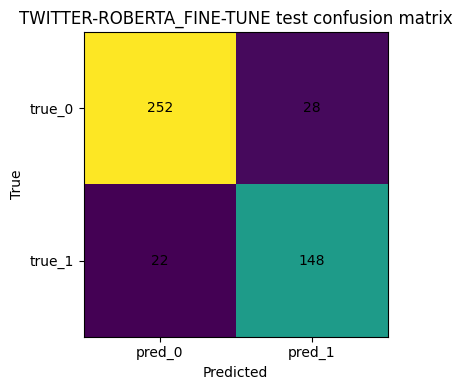

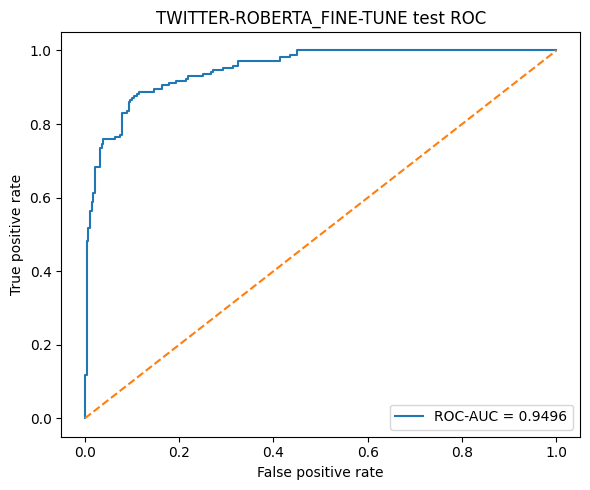

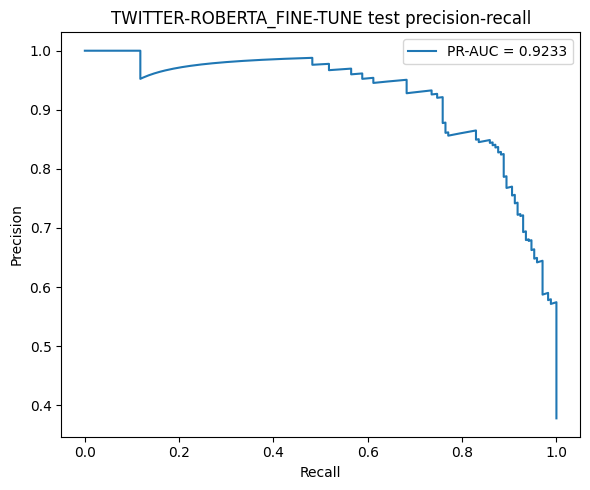

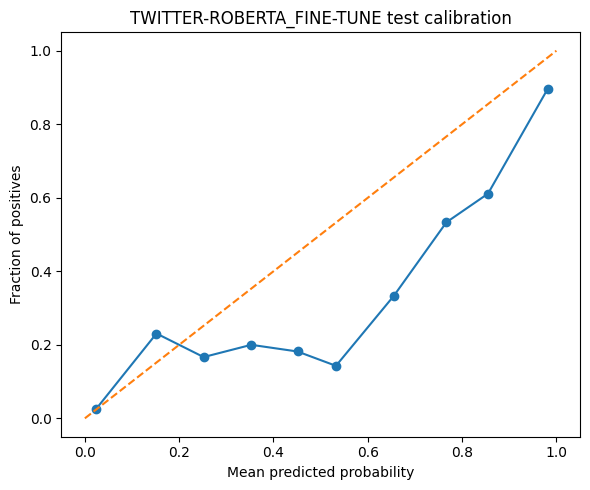

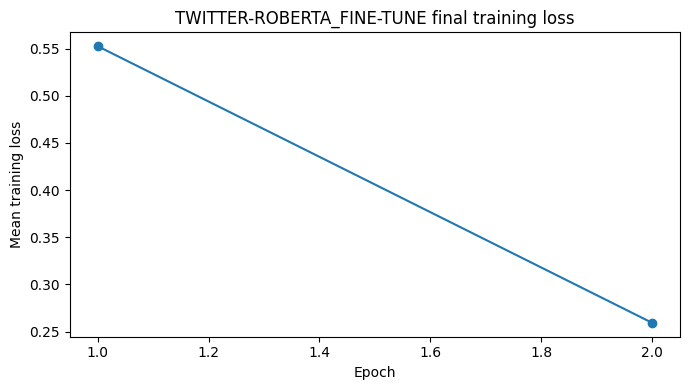

In [15]:
# ============================================================
# 15. Plot evaluation curves and confusion matrix
# ============================================================

def save_confusion_matrix_plot(y_true, y_prob, threshold, path, title):
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["pred_0", "pred_1"])
    ax.set_yticklabels(["true_0", "true_1"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def save_roc_plot(y_true, y_prob, path, title):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = safe_roc_auc(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {auc_value:.4f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def save_pr_plot(y_true, y_prob, path, title):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = safe_pr_auc(y_true, y_prob)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC = {ap:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()


def save_calibration_plot(y_true, y_prob, path, title):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(prob_pred, prob_true, marker="o")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()

save_confusion_matrix_plot(
    test_true,
    test_prob,
    selected_threshold,
    OUTPUT_DIR / "plots" / "confusion_matrix_test.png",
    f"{TECHNIQUE_NAME} test confusion matrix",
)
save_roc_plot(test_true, test_prob, OUTPUT_DIR / "plots" / "roc_curve_test.png", f"{TECHNIQUE_NAME} test ROC")
save_pr_plot(test_true, test_prob, OUTPUT_DIR / "plots" / "pr_curve_test.png", f"{TECHNIQUE_NAME} test precision-recall")
save_calibration_plot(test_true, test_prob, OUTPUT_DIR / "plots" / "calibration_curve_test.png", f"{TECHNIQUE_NAME} test calibration")

if not final_training_history.empty:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(final_training_history["epoch"], final_training_history["train_loss_mean"], marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean training loss")
    ax.set_title(f"{TECHNIQUE_NAME} final training loss")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "final_training_loss.png", dpi=200, bbox_inches="tight")
    plt.show()


In [16]:
# ============================================================
# 16. Global interpretability: gradient x embedding token attribution summary
# ============================================================

SPECIAL_TOKEN_SET = set(final_tokenizer.all_special_tokens)


def clean_token_for_display(token):
    # RoBERTa uses Ġ for beginning-of-word spaces. Keep a readable display version.
    return token.replace("Ġ", "").replace("▁", "")


def gradient_x_embedding_attribution(model, tokenizer, text, target_class=1, max_length=192):
    model.eval()
    encoded = tokenizer(
        str(text),
        truncation=True,
        max_length=int(max_length),
        return_tensors="pt",
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    embeddings = model.get_input_embeddings()(input_ids)
    embeddings.retain_grad()
    embeddings.requires_grad_(True)

    model.zero_grad(set_to_none=True)
    outputs = model(inputs_embeds=embeddings, attention_mask=attention_mask)
    probs = torch.softmax(outputs.logits, dim=-1)[0]
    score = outputs.logits[0, int(target_class)]
    score.backward()

    grads = embeddings.grad.detach()
    attributions = (grads * embeddings.detach()).sum(dim=-1).squeeze(0).detach().cpu().numpy()
    token_ids = input_ids.squeeze(0).detach().cpu().numpy().tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    records = []
    for position, (token, token_id, attribution) in enumerate(zip(tokens, token_ids, attributions)):
        if token in SPECIAL_TOKEN_SET:
            continue
        records.append({
            "token_position": position,
            "token": token,
            "token_display": clean_token_for_display(token),
            "token_id": int(token_id),
            "attribution_to_positive_logit": float(attribution),
            "abs_attribution_to_positive_logit": float(abs(attribution)),
            "positive_probability": float(probs[1].detach().cpu()),
        })
    return records

# Global summary is computed over a capped sample to keep runtime reasonable.
attr_sample = test_predictions.copy()
attr_sample["priority"] = 0
attr_sample.loc[attr_sample["error_type"].isin(["false_positive", "false_negative"]), "priority"] = 1
attr_sample = (
    attr_sample
    .sort_values(["priority", "y_prob"], ascending=[False, False])
    .head(CONFIG["explainability"]["max_global_attribution_examples"])
)

global_token_rows = []
for _, row in attr_sample.iterrows():
    try:
        records = gradient_x_embedding_attribution(
            final_model,
            final_tokenizer,
            row["text"],
            target_class=CONFIG["positive_label"],
            max_length=best_config["max_length"],
        )
        for rec in records:
            rec["row_id"] = row["row_id"]
            rec["y_true"] = row["y_true"]
            rec["y_pred"] = row["y_pred"]
            rec["error_type"] = row["error_type"]
            global_token_rows.append(rec)
    except RuntimeError as e:
        print(f"Attribution skipped for row_id={row['row_id']}: {e}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

global_token_attributions = pd.DataFrame(global_token_rows)

if not global_token_attributions.empty:
    global_summary = (
        global_token_attributions
        .groupby("token_display", as_index=False)
        .agg(
            mean_attribution_to_positive_logit=("attribution_to_positive_logit", "mean"),
            mean_abs_attribution_to_positive_logit=("abs_attribution_to_positive_logit", "mean"),
            occurrence_count=("token_display", "size"),
        )
        .sort_values("mean_attribution_to_positive_logit", ascending=False)
    )
    global_token_attributions.to_csv(
        OUTPUT_DIR / "interpretability" / "global_token_attributions_long.csv",
        index=False,
    )
    global_summary.to_csv(
        OUTPUT_DIR / "interpretability" / "global_token_attribution_summary.csv",
        index=False,
    )
    global_summary.head(CONFIG["explainability"]["top_n_global"]).to_csv(
        OUTPUT_DIR / "interpretability" / "top_positive_tokens_by_gradient.csv",
        index=False,
    )
    global_summary.tail(CONFIG["explainability"]["top_n_global"]).sort_values(
        "mean_attribution_to_positive_logit",
        ascending=True,
    ).to_csv(
        OUTPUT_DIR / "interpretability" / "top_negative_tokens_by_gradient.csv",
        index=False,
    )
    display(global_summary.head(20))
else:
    print("No global attribution rows were produced.")


,token_display,mean_attribution_to_positive_logit,mean_abs_attribution_to_positive_logit,occurrence_count
171,ching,0.384056,0.384056,1
547,oe,0.286295,0.286295,1
610,power,0.269536,0.271069,4
599,pet,0.269094,0.269094,1
310,forget,0.227119,0.227119,1
113,basically,0.198067,0.198067,1
204,cry,0.196263,0.196263,1
844,wash,0.181753,0.181753,1
367,hopes,0.180479,0.180479,1
761,tear,0.170782,0.170782,1


In [17]:
# ============================================================
# 17. Local interpretability for selected test examples
# ============================================================

local_parts = []
n = CONFIG["explainability"]["local_examples_per_bucket"]

local_parts.append(
    test_predictions[test_predictions["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(explanation_bucket="highest_confidence_false_positive")
)
local_parts.append(
    test_predictions[test_predictions["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(explanation_bucket="highest_confidence_false_negative")
)
local_parts.append(
    test_predictions[test_predictions["correct"]]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(explanation_bucket="highest_confidence_true_positive")
)
local_parts.append(
    test_predictions[test_predictions["correct"]]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(explanation_bucket="highest_confidence_true_negative")
)

local_examples = pd.concat(local_parts, ignore_index=True).drop_duplicates("row_id")
local_records = []
local_long_rows = []

for _, row in local_examples.iterrows():
    try:
        token_records = gradient_x_embedding_attribution(
            final_model,
            final_tokenizer,
            row["text"],
            target_class=CONFIG["positive_label"],
            max_length=best_config["max_length"],
        )
        token_df = pd.DataFrame(token_records)
        if token_df.empty:
            top_positive = []
            top_negative = []
        else:
            token_df["row_id"] = row["row_id"]
            token_df["explanation_bucket"] = row["explanation_bucket"]
            local_long_rows.append(token_df)
            top_positive = (
                token_df.sort_values("attribution_to_positive_logit", ascending=False)
                .head(CONFIG["explainability"]["top_n_local_tokens"])
                [["token_display", "attribution_to_positive_logit"]]
                .to_dict("records")
            )
            top_negative = (
                token_df.sort_values("attribution_to_positive_logit", ascending=True)
                .head(CONFIG["explainability"]["top_n_local_tokens"])
                [["token_display", "attribution_to_positive_logit"]]
                .to_dict("records")
            )

        local_records.append({
            "row_id": row["row_id"],
            "explanation_bucket": row["explanation_bucket"],
            "y_true": row["y_true"],
            "y_pred": row["y_pred"],
            "y_prob": row["y_prob"],
            "error_type": row["error_type"],
            "text_preview": row["text"][:CONFIG["explainability"]["max_text_chars_for_display"]],
            "top_positive_tokens_json": json.dumps(make_json_safe(top_positive)),
            "top_negative_tokens_json": json.dumps(make_json_safe(top_negative)),
        })
    except RuntimeError as e:
        print(f"Local attribution skipped for row_id={row['row_id']}: {e}")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

local_explanations = pd.DataFrame(local_records)
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_token_attribution_explanations.csv",
    index=False,
)

if local_long_rows:
    local_long_df = pd.concat(local_long_rows, ignore_index=True)
    local_long_df.to_csv(
        OUTPUT_DIR / "interpretability" / "local_token_attributions_long.csv",
        index=False,
    )

display(local_explanations.head(20))


,row_id,explanation_bucket,y_true,y_pred,y_prob,error_type,text_preview,top_positive_tokens_json,top_negative_tokens_json
0,ex_001618,highest_confidence_false_positive,0,1,0.996903,false_positive,you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatu...,"[{""token_display"": ""despicable"", ""attribution_to_positive_logit"": 0.02599104307591915}, {""token_display"": ""animal"", ...","[{""token_display"": ""plan"", ""attribution_to_positive_logit"": -0.01568685844540596}, {""token_display"": ""has"", ""attribu..."
1,ex_001428,highest_confidence_false_positive,0,1,0.992818,false_positive,i am going to murder that fucking vagina,"[{""token_display"": ""going"", ""attribution_to_positive_logit"": 0.02431141585111618}, {""token_display"": ""fucking"", ""att...","[{""token_display"": ""to"", ""attribution_to_positive_logit"": -0.04444681853055954}, {""token_display"": ""i"", ""attribution..."
2,ex_000334,highest_confidence_false_positive,0,1,0.990683,false_positive,these animals have not been hunted for a long time so have lost their fear of men they will either need to be hunted...,"[{""token_display"": ""either"", ""attribution_to_positive_logit"": 0.06455078721046448}, {""token_display"": ""fear"", ""attri...","[{""token_display"": ""men"", ""attribution_to_positive_logit"": -0.16804873943328857}, {""token_display"": ""they"", ""attribu..."
3,ex_001873,highest_confidence_false_positive,0,1,0.982598,false_positive,sable is a whore and a cunt sunny destroys sable via,"[{""token_display"": ""able"", ""attribution_to_positive_logit"": 0.16643336415290833}, {""token_display"": ""s"", ""attributio...","[{""token_display"": ""destroys"", ""attribution_to_positive_logit"": -0.14299756288528442}, {""token_display"": ""able"", ""at..."
4,ex_002940,highest_confidence_false_positive,0,1,0.981126,false_positive,ching chong,"[{""token_display"": ""ching"", ""attribution_to_positive_logit"": 0.38405564427375793}, {""token_display"": ""ong"", ""attribu...","[{""token_display"": ""ch"", ""attribution_to_positive_logit"": 0.05793780833482742}, {""token_display"": ""ong"", ""attributio..."
5,ex_002022,highest_confidence_false_positive,0,1,0.977479,false_positive,normal woman degenerates into a cunt,"[{""token_display"": ""ates"", ""attribution_to_positive_logit"": 0.0323837473988533}, {""token_display"": ""a"", ""attribution...","[{""token_display"": ""normal"", ""attribution_to_positive_logit"": -0.316261887550354}, {""token_display"": ""woman"", ""attri..."
6,ex_000972,highest_confidence_false_positive,0,1,0.946678,false_positive,agreed but address traitor to that list as well ok thank you buildthewall lockthemup indiana now,"[{""token_display"": ""lock"", ""attribution_to_positive_logit"": 0.13432350754737854}, {""token_display"": ""up"", ""attributi...","[{""token_display"": ""ind"", ""attribution_to_positive_logit"": -0.08181692659854889}, {""token_display"": ""list"", ""attribu..."
7,ex_002866,highest_confidence_false_positive,0,1,0.945065,false_positive,is a rag head the same as a camel swagger,"[{""token_display"": ""a"", ""attribution_to_positive_logit"": 0.07178409397602081}, {""token_display"": ""a"", ""attribution_t...","[{""token_display"": ""head"", ""attribution_to_positive_logit"": -0.2970948815345764}, {""token_display"": ""is"", ""attributi..."
8,ex_001802,highest_confidence_false_negative,1,0,0.036459,false_negative,would you like to be called a retarded then stop acting like one,"[{""token_display"": ""you"", ""attribution_to_positive_logit"": 0.07015401870012283}, {""token_display"": ""retarded"", ""attr...","[{""token_display"": ""a"", ""attribution_to_positive_logit"": -0.16467973589897156}, {""token_display"": ""would"", ""attribut..."
9,ex_000403,highest_confidence_false_negative,1,0,0.038997,false_negative,power bomb that hoe,"[{""token_display"": ""that"", ""attribution_to_positive_logit"": 1.1821833848953247}, {""token_display"": ""power"", ""attribu...","[{""

In [18]:
# ============================================================
# 18. Error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(error_df["y_prob"] - error_df["threshold"])


def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if row["y_prob"] >= 0.90 or row["y_prob"] <= 0.10:
        return "high_confidence"
    return "moderate_confidence"

error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

if "local_explanations" in globals() and not local_explanations.empty:
    explanation_cols = local_explanations[
        ["row_id", "top_positive_tokens_json", "top_negative_tokens_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(explanation_cols, on="row_id", how="left")

if CONFIG["error_analysis"]["include_text_preview"]:
    error_df["text_preview"] = error_df["text"].str.slice(0, CONFIG["error_analysis"]["text_preview_chars"])

error_df.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)

review_parts = []
n = CONFIG["error_analysis"]["examples_per_bucket"]

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(review_bucket="highest_confidence_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(review_bucket="highest_confidence_false_negative")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_negative")
)

review_df = pd.concat(review_parts, ignore_index=True)
review_df.to_csv(OUTPUT_DIR / "error_analysis" / "manual_review_queue_test.csv", index=False)

error_summary = (
    error_df
    .groupby(["error_type", "confidence_bucket"])
    .size()
    .reset_index(name="count")
    .sort_values(["error_type", "confidence_bucket"])
)
error_summary.to_csv(OUTPUT_DIR / "error_analysis" / "error_summary.csv", index=False)

display(error_summary)
display(review_df.head(20))


,error_type,confidence_bucket,count
0,correct,high_confidence,316
1,correct,moderate_confidence,78
2,correct,near_threshold,6
3,false_negative,high_confidence,5
4,false_negative,moderate_confidence,16
5,false_negative,near_threshold,1
6,false_positive,high_confidence,15
7,false_positive,moderate_confidence,11
8,false_positive,near_threshold,2


,row_id,text,y_true,split,y_prob,threshold,y_pred,correct,error_type,text_hash,abs_distance_to_threshold,confidence_bucket,manual_error_category,manual_notes,top_positive_tokens_json,top_negative_tokens_json,text_preview,review_bucket
0,ex_001618,you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatu...,0,test,0.996903,0.72,1,False,false_positive,d0c41a9aa6434c80,0.276903,high_confidence,,,"[{""token_display"": ""despicable"", ""attribution_to_positive_logit"": 0.02599104307591915}, {""token_display"": ""animal"", ...","[{""token_display"": ""plan"", ""attribution_to_positive_logit"": -0.01568685844540596}, {""token_display"": ""has"", ""attribu...",you are an evil despicable animal and i am sure eventually you will get yours god has a special plan for vile creatu...,highest_confidence_false_positive
1,ex_001428,i am going to murder that fucking vagina,0,test,0.992818,0.72,1,False,false_positive,05c512c6e5feee82,0.272818,high_confidence,,,"[{""token_display"": ""going"", ""attribution_to_positive_logit"": 0.02431141585111618}, {""token_display"": ""fucking"", ""att...","[{""token_display"": ""to"", ""attribution_to_positive_logit"": -0.04444681853055954}, {""token_display"": ""i"", ""attribution...",i am going to murder that fucking vagina,highest_confidence_false_positive
2,ex_000334,these animals have not been hunted for a long time so have lost their fear of men they will either need to be hunted...,0,test,0.990683,0.72,1,False,false_positive,bfe199c9549c1956,0.270683,high_confidence,,,"[{""token_display"": ""either"", ""attribution_to_positive_logit"": 0.06455078721046448}, {""token_display"": ""fear"", ""attri...","[{""token_display"": ""men"", ""attribution_to_positive_logit"": -0.16804873943328857}, {""token_display"": ""they"", ""attribu...",these animals have not been hunted for a long time so have lost their fear of men they will either need to be hunted...,highest_confidence_false_positive
3,ex_001873,sable is a whore and a cunt sunny destroys sable via,0,test,0.982598,0.72,1,False,false_positive,c601ac41b5c189e4,0.262598,high_confidence,,,"[{""token_display"": ""able"", ""attribution_to_positive_logit"": 0.16643336415290833}, {""token_display"": ""s"", ""attributio...","[{""token_display"": ""destroys"", ""attribution_to_positive_logit"": -0.14299756288528442}, {""token_display"": ""able"", ""at...",sable is a whore and a cunt sunny destroys sable via,highest_confidence_false_positive
4,ex_002940,ching chong,0,test,0.981126,0.72,1,False,false_positive,243f34dc599b49ac,0.261126,high_confidence,,,"[{""token_display"": ""ching"", ""attribution_to_positive_logit"": 0.38405564427375793}, {""token_display"": ""ong"", ""attribu...","[{""token_display"": ""ch"", ""attribution_to_positive_logit"": 0.05793780833482742}, {""token_display"": ""ong"", ""attributio...",ching chong,highest_confidence_false_positive
5,ex_002022,normal woman degenerates into a cunt,0,test,0.977479,0.72,1,False,false_positive,d00768b321750f5d,0.257479,high_confidence,,,"[{""token_display"": ""ates"", ""attribution_to_positive_logit"": 0.0323837473988533}, {""token_display"": ""a"", ""attribution...","[{""token_display"": ""normal"", ""attribution_to_positive_logit"": -0.316261887550354}, {""token_display"": ""woman"", ""attri...",normal woman degenerates into a cunt,highest_confidence_false_positive
6,ex_000972,agreed but address traitor to that list as well ok thank you buildthewall lockthemup indiana now,0,test,0.946678,0.72,1,False,false_positive,8a10c19cd58255ca,0.226678,high_confidence,,,"[{""token_display"": ""lock"", ""attribution_to_positive_logit"": 0.13432350754737854}, {""token_display"": ""up"", ""attributi...","[{""token_display"": ""ind"", ""attribution_to_positive_logit"": -0.08181692659854889}, {""token_display"": ""list"", ""attribu...",agreed but address traitor to that list as well ok thank you buildthewall lockthemup indiana now,highest_confidence_false_positive
7,ex_0

In [19]:
# ============================================================
# 19. Save experiment metadata and output README
# ============================================================

try:
    import transformers
    transformers_version = transformers.__version__
except Exception:
    transformers_version = None

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "dataset_manifest": dataset_manifest,
    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "torch_version": torch.__version__,
        "transformers_version": transformers_version,
        "cuda_available": torch.cuda.is_available(),
    },
    "model_selection": {
        "ablation_split": "validation",
        "primary_selection_metric": CONFIG["threshold_selection"]["metric"],
        "test_set_used_for_selection": False,
    },
    "final_evaluation": {
        "test_split_used_once_after_selection": True,
        "threshold_selected_on": "validation",
    },
    "probability_modeling": {
        "method": "softmax probability from fine-tuned transformer classifier head",
        "fit_on": "train split only, with validation used for hyperparameter and threshold selection",
    },
    "xai_method": {
        "global": "Gradient x Embedding token attribution summary over capped test sample",
        "local": "Gradient x Embedding token attribution for selected test examples",
        "note": "Token attribution is useful for explanation but should be interpreted as an approximate post-hoc explanation, not a causal proof.",
    },
    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "error_analysis": "error_analysis/",
        "training_logs": "training_logs/",
    },
}

save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Technique rationale

This notebook tests a context-aware social-media RoBERTa transformer after six shallower strategies plateaued around similar accuracy. The goal is to test whether preserving sentence context and leveraging social-media pretraining improves extremism classification beyond sparse TF-IDF and static embedding baselines.

Default checkpoint: `{CONFIG['pretrained_model_name_or_path']}`

## Research protocol

- Canonical train/validation/test splits are loaded from `split_assignments.csv`.
- Hyperparameters are selected using the validation split only.
- The decision threshold is selected on the validation split only.
- The held-out test split is evaluated once after selection.
- The notebook saves metrics, predictions, plots, model artifacts, gradient-based token attribution outputs, and error-analysis files.

## Explainability outputs

- `interpretability/global_token_attributions_long.csv`
- `interpretability/global_token_attribution_summary.csv`
- `interpretability/top_positive_tokens_by_gradient.csv`
- `interpretability/top_negative_tokens_by_gradient.csv`
- `interpretability/local_token_attribution_explanations.csv`
- `interpretability/local_token_attributions_long.csv`

## Important interpretation note

Gradient-based token attributions are post-hoc explanations. They are useful for comparing lexical/contextual cues across models, but they should be combined with manual error analysis and counterfactual deletion tests before making strong claims about explanation faithfulness.
"""

with open(OUTPUT_DIR / "README.md", "w") as f:
    f.write(readme_text)

print("Saved metadata and README to:", OUTPUT_DIR)


Saved metadata and README to: /kaggle/working/experiments/TWITTER-ROBERTA_FINE-TUNE


In [20]:
# ============================================================
# 20. Zip outputs for download / Google Drive storage
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created zip file:")
print(zip_path)

print("\nUpload this zip to Google Drive:")
print(f"Extremism-Classification-Research/01_model_outputs/{TECHNIQUE_NAME}/")


Created zip file:
/kaggle/working/TWITTER-ROBERTA_FINE-TUNE_outputs.zip

Upload this zip to Google Drive:
Extremism-Classification-Research/01_model_outputs/TWITTER-ROBERTA_FINE-TUNE/
